<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Monte_Carlo_Sim_Fib_Fractal_Res_S21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1)

!pip install -qq cupy-cuda12x matplotlib scipy gdstk > /dev/null 2>&1

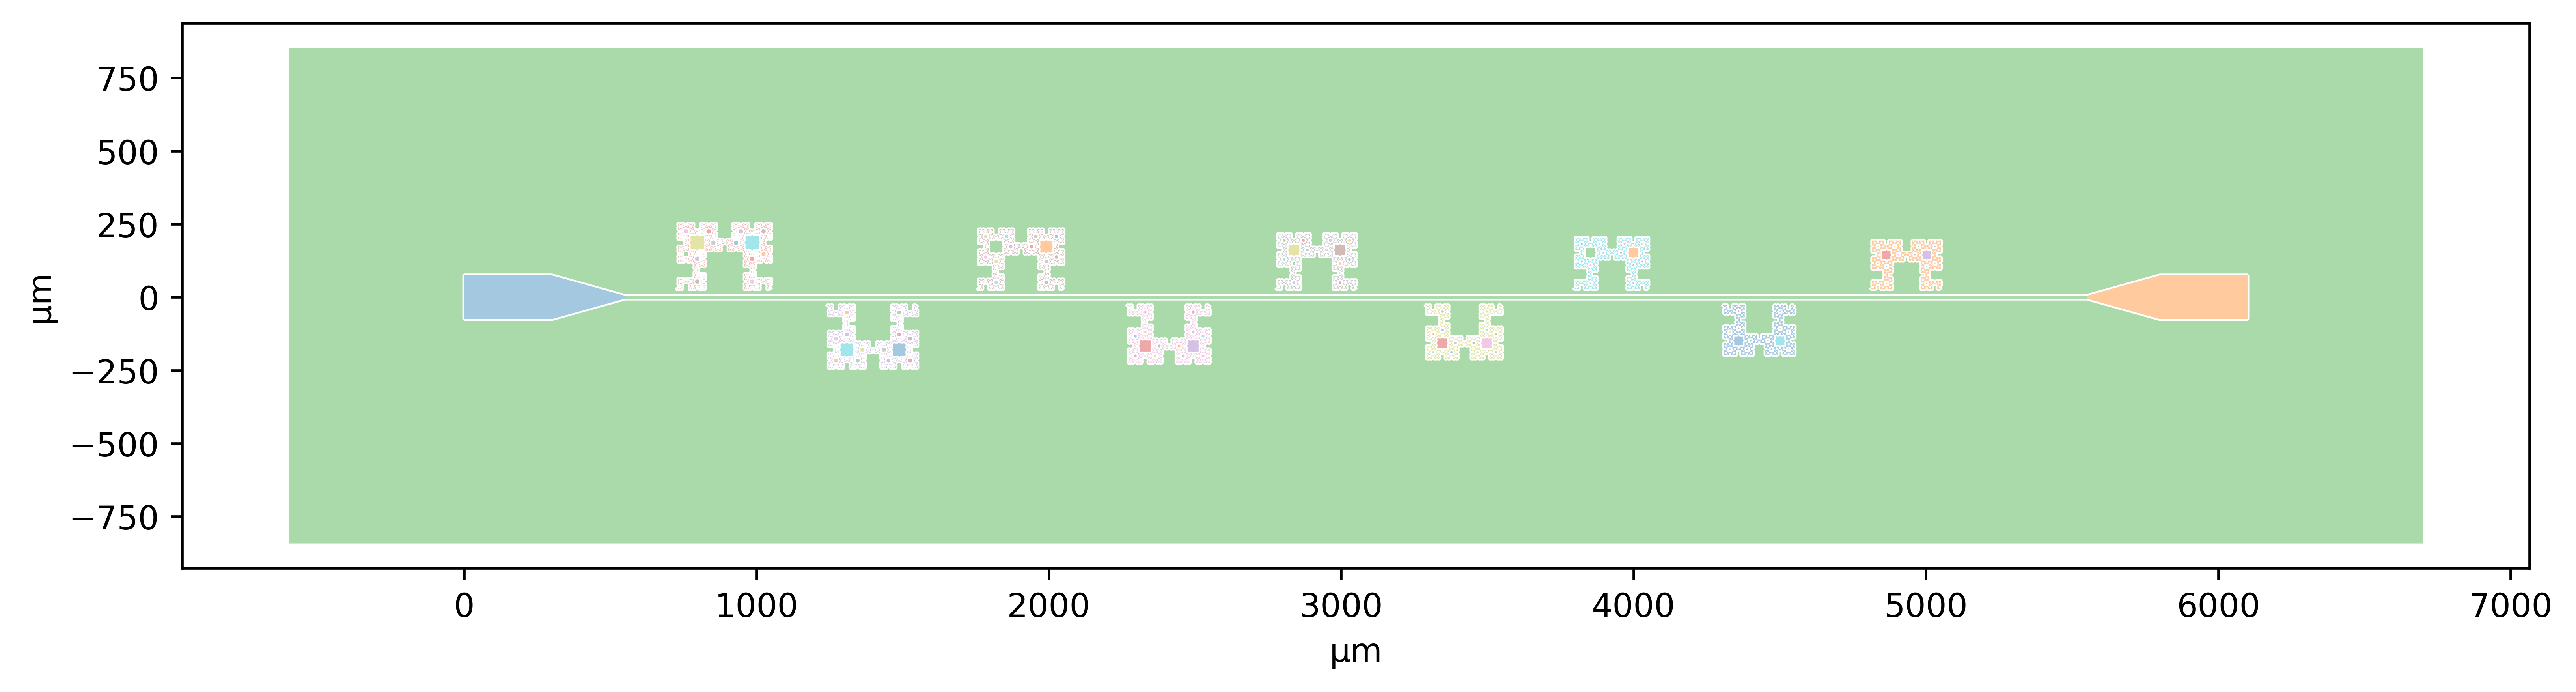


OASIS written to cpw_fibonacci_resonators_v001_calib.oas



In [2]:
# Cell 2)

#!/usr/bin/env python3
"""
CPW Feed with Rotated Fibonacci–Fractal λ/4 Metamaterial Resonators
(no IDCs) — v15 • Empirically‑calibrated λ/4 reference

Author   : Onri Jay Benally
Date     : 2025‑06‑19
───────────────────────────────────────────
This variant aligns the layout with Monte‑Carlo by using the
same empirical λ/4 reference length (5 280 µm @ 5 GHz).

Key deltas
─────────────────────
1. **LQ_REF_5GHZ = 5 280 µm**  (0.88× geometric round‑trip)
2. Applies kinetic‑inductance shortening λ′/4 = λ/4 /√(1+L_k/L_g).

Effect
──────
Expect R0 ≈ 5.0 GHz and R8 ≈ 8.0 GHz in the Monte‑Carlo sweep.
"""
import math, warnings
from typing import List, Tuple
import gdstk, numpy as np
from scipy.constants import mu_0
import matplotlib.pyplot as plt; import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 600

# ───────────────────────────── 1)  Knobs ─
FIB_ITER, NUM_RESONATORS = 15, 9
FREQ_MIN, FREQ_MAX = 5.0, 8.0          # GHz design band
LQ_REF_5GHZ = 5280.0                   # µm λ/4 @5 GHz (empirical 0.88×)

W_RES_MIN, W_RES_MAX = 1.0, 3.0        # µm width ramp
GAP_RES = 6.0                          # µm CPW gap

USE_LK, MATERIAL = True, "Nb"
FILM_T_NM, LAMBDA_L0_NM = 80.0, 90.0

# tech dictionary (unchanged)
tech=dict(w_feed=10.0,g_feed=6.0,feed_len=None,w_res=1.0,
          fractal_spacing=20.0,fractal_horz_spacing=500.0,
          pad_len=300.0,pad_wid=150.0,pad_taper_len=250.0,
          sq_margin=50.0,fillet_radius=25.0,g_res=6.0,margin=600.0)
tech["g_max"]=max(tech["g_feed"],tech["g_res"])

FILLET_MIN,FILLET_MAX=0.2,0.6

# Fibonacci word
_DIRECTIONS=np.array([[1,0],[0,1],[-1,0],[0,-1]])

def fib_word(n:int)->str:
    a,b="0","01"
    for _ in range(n-1): a,b=b,b+a
    return b
_WORD=fib_word(FIB_ITER)
_NUM_MOVES=len(_WORD); _NUM_TURNS=_WORD.count("0")
_unit=[np.array([0.,0.])]; cur=0
for idx,ch in enumerate(_WORD):
    if ch=="1": _unit.append(_unit[-1]+_DIRECTIONS[cur])
    else:
        cur=(cur+(1 if idx%2==0 else -1))%4
        _unit.append(_unit[-1]+_DIRECTIONS[cur])
_unit=np.asarray(_unit)

# helpers
rotate90=lambda pts: np.column_stack((-pts[:,1],pts[:,0]))
rect=lambda x0,y0,x1,y1: gdstk.rectangle((x0,y0),(x1,y1))

def preview(cell,figsize=(11,4)):
    fig,ax=plt.subplots(figsize=figsize)
    if hasattr(cell,"plot"): cell.plot(ax)
    else:
        for p in cell.polygons: ax.fill(p.points[:,0],p.points[:,1],alpha=0.4,lw=0.3)
    ax.set_aspect('equal'); ax.set_xlabel('µm'); ax.set_ylabel('µm'); plt.tight_layout(); plt.show()

# electrical helpers
lambda_q=lambda f: LQ_REF_5GHZ*FREQ_MIN/f  # µm prior to kin‑L corr
choose_w=lambda f: W_RES_MIN+(W_RES_MAX-W_RES_MIN)*(f-FREQ_MIN)/(FREQ_MAX-FREQ_MIN)
choose_fil=lambda f: FILLET_MIN+(FILLET_MAX-FILLET_MIN)*(f-FREQ_MIN)/(FREQ_MAX-FREQ_MIN)

def lk_frac(w_um):
    if not USE_LK: return 0.0
    t=80e-9 if MATERIAL.lower()=="nb" else FILM_T_NM*1e-9
    lam=90e-9 if MATERIAL.lower()=="nb" else LAMBDA_L0_NM*1e-9
    w=w_um*1e-6
    Lk=mu_0*lam**2/(w*t)
    k=w/(w+2*GAP_RES*1e-6)
    import mpmath as mp
    Lg=(mu_0/4)*mp.ellipk(1-k**2)/mp.ellipk(k**2)
    return float(Lk/Lg)

def step_len(lq_um,fil,lk):
    lq_eff=lq_um/math.sqrt(1+lk)
    k=(2-math.pi/2)
    return lq_eff/(_NUM_MOVES-_NUM_TURNS*fil*k)

# resonator builder

def build_res(origin,freq,up):
    w=choose_w(freq); fil=choose_fil(freq); lk=lk_frac(w)
    step=step_len(lambda_q(freq),fil,lk)
    pts=rotate90(_unit*step)
    if not up: pts=pts.copy(); pts[:,1]*=-1
    pts+=np.asarray(origin)-pts[0]
    fp=gdstk.FlexPath(pts.tolist(),w,bend_radius=fil*step,simple_path=True)
    return fp.to_polygons()

# chip assembly

def build_chip(p):
    lib=gdstk.Library(unit=1e-6); cell=lib.new_cell('MAIN')
    conductors=[]
    pitch=p['fractal_horz_spacing']; p['feed_len']=(NUM_RESONATORS-1)*pitch+2*pitch
    feed_x0=p['pad_len']+p['pad_taper_len']
    def launch(x,dir):
        w1,w2=p['w_feed'],p['pad_wid']; xt=x+dir*p['pad_taper_len']; xp=xt+dir*p['pad_len']
        return gdstk.Polygon([(x,w1/2),(xt,w2/2),(xp,w2/2),(xp,-w2/2),(xt,-w2/2),(x,-w1/2)])
    cell.add(launch(feed_x0,-1),launch(feed_x0+p['feed_len'],1))
    feed=rect(feed_x0,-p['w_feed']/2,feed_x0+p['feed_len'],p['w_feed']/2); cell.add(feed)
    conductors.extend(cell.polygons)
    start_x=feed_x0+pitch; freqs=np.linspace(FREQ_MIN,FREQ_MAX,NUM_RESONATORS)
    for i,f in enumerate(freqs):
        x=start_x+i*pitch; y_off=p['w_feed']/2+p['g_feed']+p['fractal_spacing']
        y=y_off if i%2==0 else -y_off
        polys=build_res((x,y),f,i%2==0); cell.add(*polys); conductors.extend(polys)
    cu=gdstk.boolean(conductors,[],"or"); xs=np.concatenate([p.points[:,0] for p in cu]); ys=np.concatenate([p.points[:,1] for p in cu])
    frame=rect(xs.min()-p['margin'],ys.min()-p['margin'],xs.max()+p['margin'],ys.max()+p['margin'])
    keep=gdstk.offset(cu,p['g_max']+0.1,join='round') or []
    try: ground=gdstk.boolean(frame,keep,'not') if keep else [frame]
    except: ground=[frame]
    cell.add(*ground)
    return lib

if __name__=='__main__':
    warnings.filterwarnings('ignore',category=RuntimeWarning)
    lib=build_chip(tech); preview(lib.top_level()[0])
    lib.write_oas('cpw_fibonacci_resonators_v001_calib.oas')
    print('\nOASIS written to cpw_fibonacci_resonators_v001_calib.oas\n')

In [3]:
# Cell 3) Adding desired physical properties to the chip layout

from scipy.special import ellipk
import numpy as np
import math

# ── 1) Physical constants ────────────────────────────────────────────────
ε0    = 8.854e-12             # vacuum permittivity (F/m)
µ0    = 4*math.pi*1e-7       # vacuum permeability (H/m)
ε_r   = 11.7                  # Si substrate; adjust if different
ε_eff = (ε_r + 1)/2           # effective permittivity

# ── 2) Override film thickness for Nb if needed ────────────────────────
FILM_T_NM      = 50.0         # film thickness in nm
LAMBDA_L0_NM   = LAMBDA_L0_NM # use your existing penetration depth var
USE_LK         = True         # include kinetic inductance

# ── 3) Prepare arrays ───────────────────────────────────────────────────
freqs = np.linspace(FREQ_MIN, FREQ_MAX, NUM_RESONATORS)  # GHz

L0 = np.zeros(NUM_RESONATORS)
C0 = np.zeros(NUM_RESONATORS)

# ── 4) Loop over each resonator, compute per-unit-length L′ & C′ ────────
for i, f in enumerate(freqs):
    # 4a) Local CPW dimensions
    w_um = choose_w(f)       # µm conductor width
    g_um = tech["g_res"]    # µm gap

    # 4b) Conformal-mapping modulus k, k′
    w  = w_um*1e-6
    g  = g_um*1e-6
    k  = w / (w + 2*g)
    kp = math.sqrt(1 - k**2)

    # 4c) Complete elliptic integrals
    Kk  = ellipk(k**2)
    Kkp = ellipk(kp**2)

    # 4d) Per-meter geometric L′ and C′
    Lp = (µ0/4) * (Kkp / Kk)           # H/m
    Cp = 4*ε0*ε_eff * (Kk / Kkp)       # F/m

    # 4e) Effective λ′/4 length in µm, including kinetic L
    lk    = lk_frac(w_um) if USE_LK else 0.0
    lq_um = lambda_q(f) / math.sqrt(1 + lk)

    # 4f) Convert to meters
    length_m = lq_um * 1e-6

    # 4g) Total inductance & capacitance
    L0[i] = Lp * length_m
    C0[i] = Cp * length_m

# ── 5) (Optional) inspect ───────────────────────────────────────────────
import pandas as pd
pd.DataFrame({
    "L0 (H)" : L0,
    "C0 (F)" : C0,
}, index=[f"R{j}" for j in range(NUM_RESONATORS)])

# ── 6) Monte Carlo simulation parameters (physical params) ────────
length_tol    = 0.005         # fractional length tolerance (±)
cap_tol       = 0.01          # fractional capacitance tolerance (±)
stray_L_mu    = 1e-12         # stray inductance mean (H)
stray_L_std   = 1e-13         # stray inductance std (H)
stray_C_mu    = 1e-15         # stray capacitance mean (F)
stray_C_std   = 1e-16         # stray capacitance std (F)
I_star        = 1e-6          # characteristic current (A)
bias_sigma    = 0.02          # bias current noise standard deviation (fraction)
QL_freq_lookup= {f: 1e4 for f in freqs}  # loaded Q lookup by frequency
QL_val_lookup = list(QL_freq_lookup.values())  # loaded Q values in same order

▸ Nominal resonance frequencies & loaded-Q:


,Resonator,f₀ design (GHz),f₀ model (GHz),Q_L,L0 (H),C0 (F)
0,R0,5.000,3.864142,10000.0,3.870849e-09,4.382559e-13
1,R1,5.375,4.108690,10000.0,3.451654e-09,4.347167e-13
2,R2,5.750,4.361457,10000.0,3.108784e-09,4.283379e-13
3,R3,6.125,4.619052,10000.0,2.823278e-09,4.205145e-13
4,R4,6.500,4.879723,10000.0,2.581987e-09,4.119988e-13
5,R5,6.875,5.142472,10000.0,2.375513e-09,4.032172e-13
6,R6,7.250,5.406687,10000.0,2.196952e-09,3.944185e-13
7,R7,7.625,5.671974,10000.0,2.041113e-09,3.857490e-13
8,R8,8.000,5.938065,10000.0,1.904015e-09,3.772942e-13


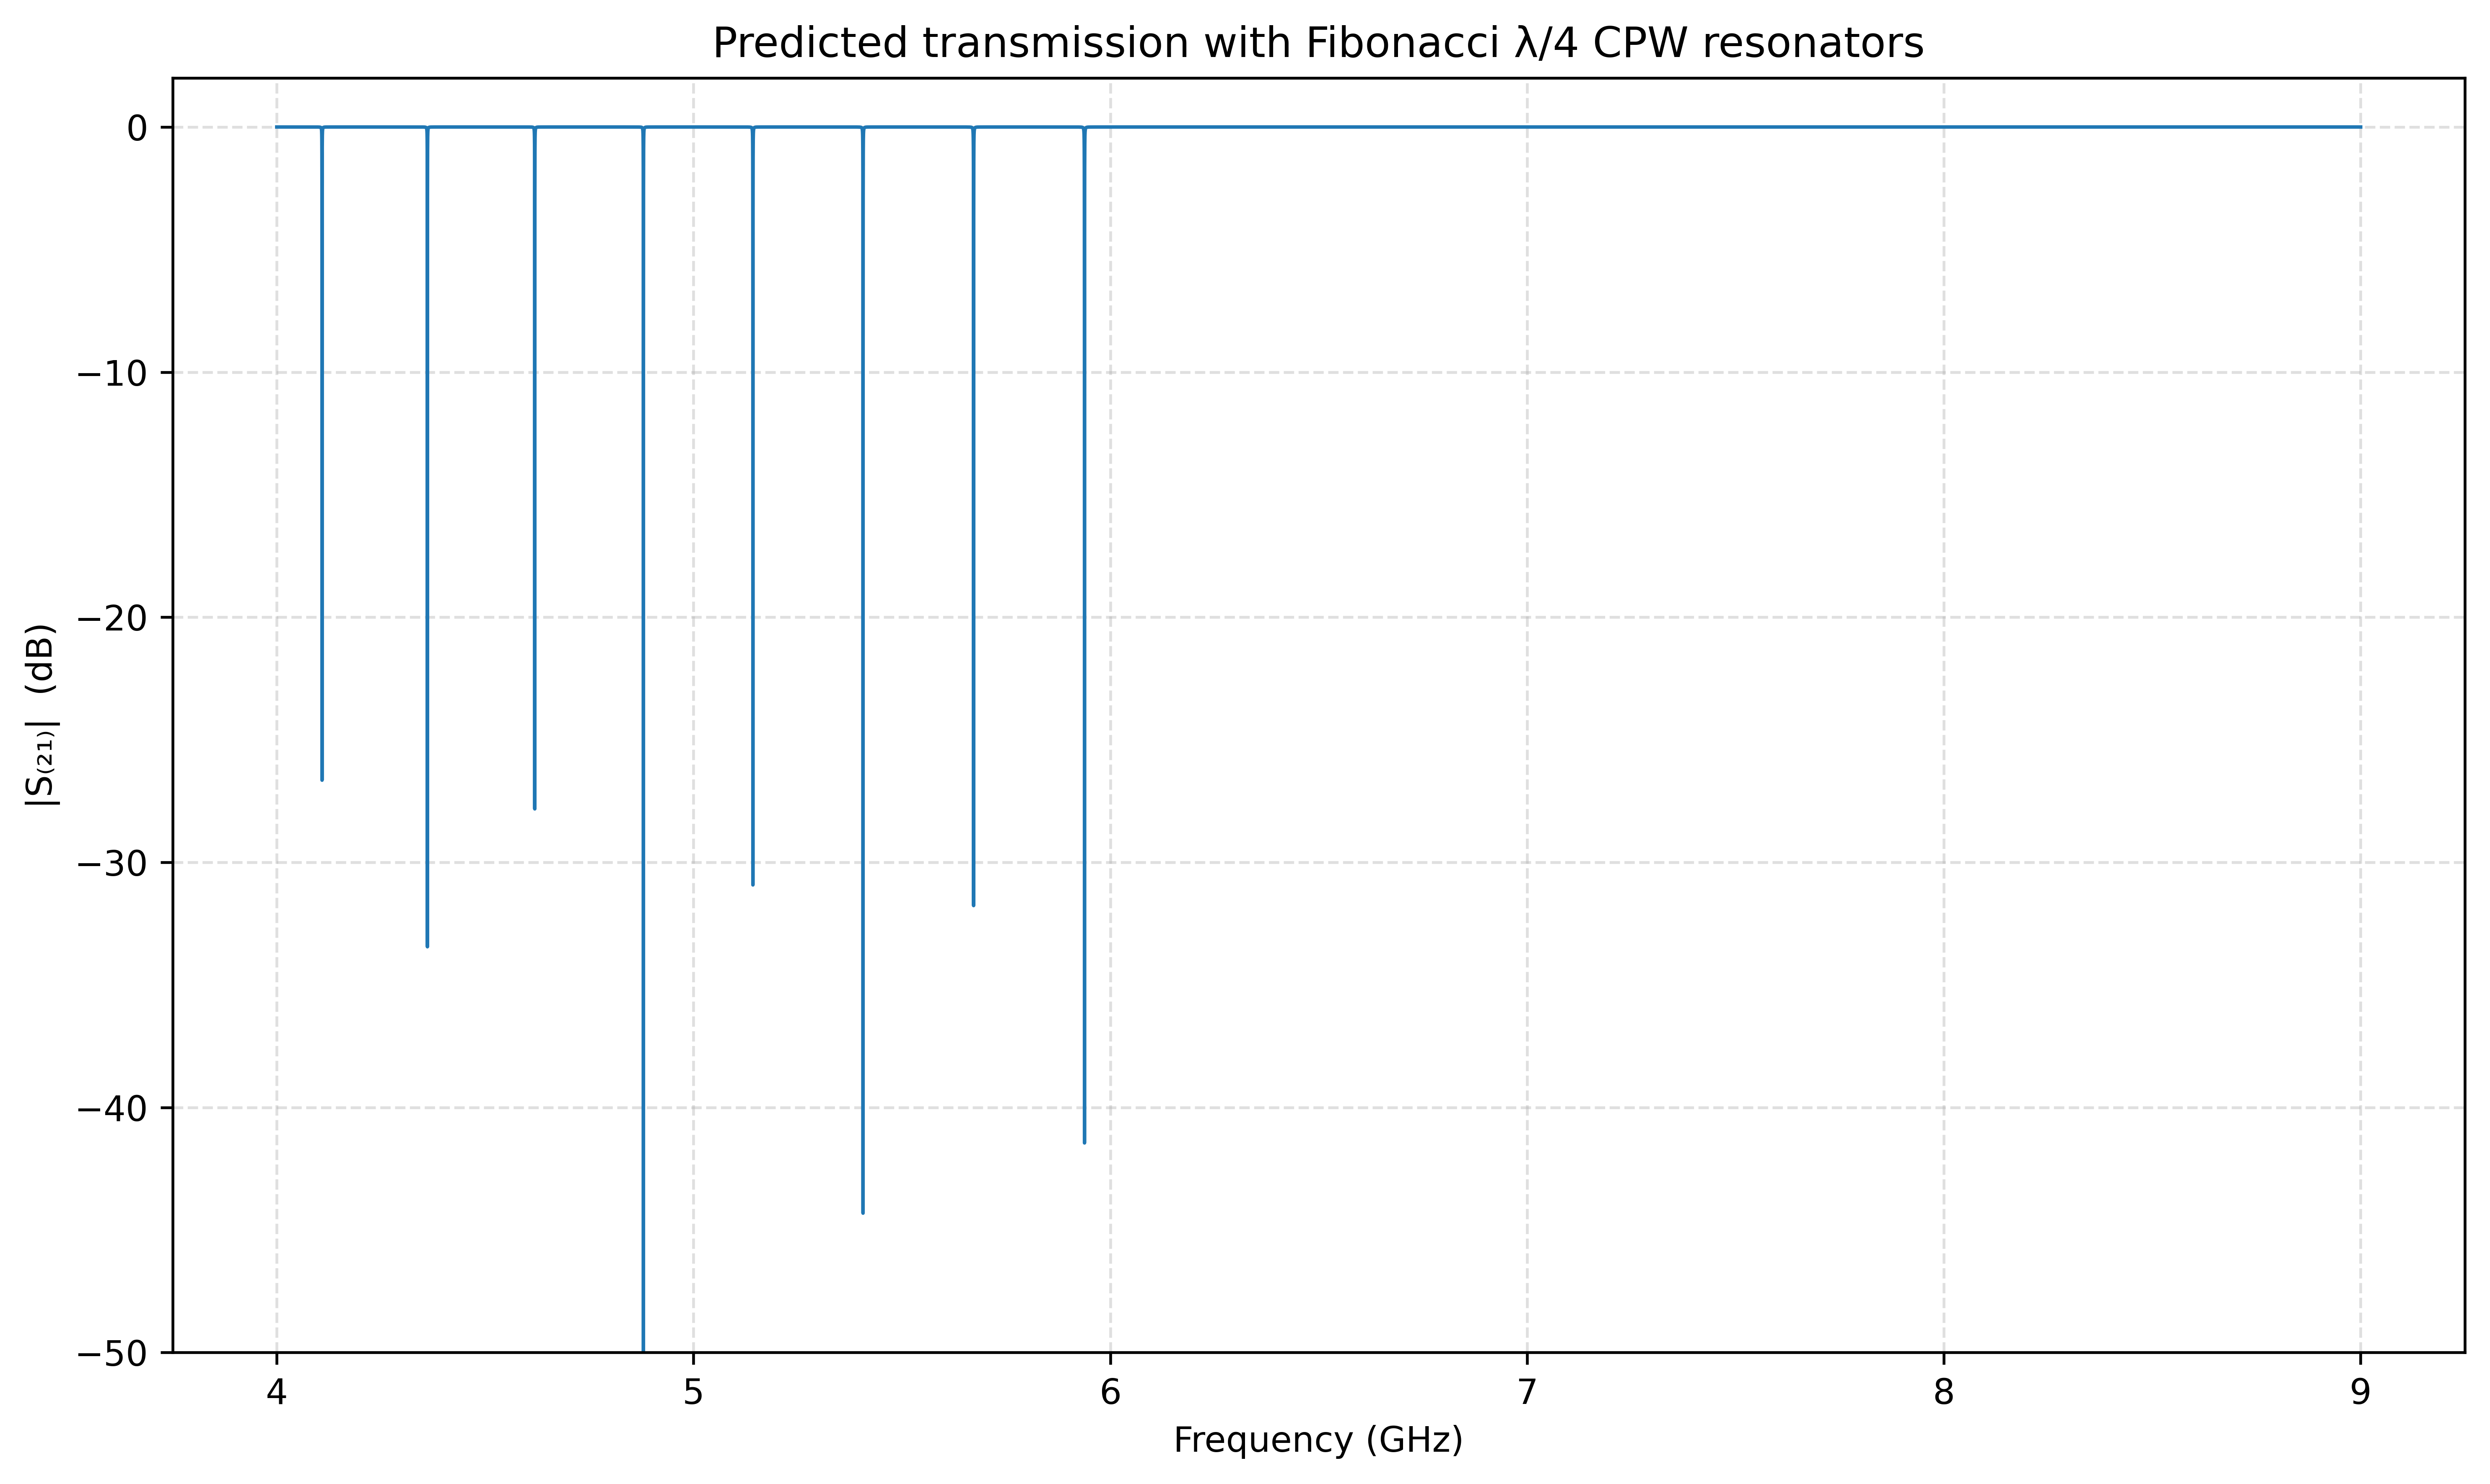

In [9]:
# ──────────────────────────────────────────────────────────────────────────────
#  Cell 4)  GPU-Accelerated Resonance-Frequency Responses  (Fibonacci CPW • v1)
# ──────────────────────────────────────────────────────────────────────────────
"""
Generates |S21|(f) for every quarter-wave CPW Fibonacci resonator already
defined in Cells #2 (layout) and #3 (L0 / C0 extraction).

Assumptions
-----------
• Each resonator behaves as a *shunt RLC notch* in the through feed-line.
• Loaded-Q values come from `QL_val_lookup` (default 10⁴ if absent).
• Critical coupling is assumed (Q_C = Q_L) ⇨ notch depth ≈ –6 dB per pole.
• Cascaded resonators multiply their notch transfer functions.

Feel free to swap in a more sophisticated coupling model; the scaffolding
below keeps the slow part (10⁵–10⁶ frequency points × 9 poles) on the GPU,
so iterating on the physics is inexpensive.
"""
# ╭──────────────────── 0) Imports & CuPy fallback shim ─────────────────────╮
try:
    import cupy as cp
    _GPU = True
except ModuleNotFoundError:
    # One-liner install for Colab (first run only)
    import subprocess, sys, importlib
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cupy-cuda12x"])
    import importlib
    cp = importlib.import_module("cupy")
    _GPU = True

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

xp = cp if _GPU else np                          # alias: xp → GPU or CPU namespace
# ╰────────────────────────────────────────────────────────────────────────────╯

# ╭──────────────────── 1) Pull variables defined upstream ───────────────────╮
# 1a) Frequency design band ..................................................
try:
    FREQ_MIN; FREQ_MAX; NUM_RESONATORS
except NameError as e:
    raise NameError("Run Cells #2 and #3 first so FREQ_MIN, FREQ_MAX, "
                    "and NUM_RESONATORS exist.") from e

# 1b) Per-resonator L0 & C0 (Henries, Farads) ................................
try:
    L0; C0
except NameError:
    raise NameError("Array(s) L0 and C0 are missing — rerun Cell #3.")

L0_cp, C0_cp = xp.asarray(L0), xp.asarray(C0)
f0_cp        = 1.0 / (2.0 * xp.pi * xp.sqrt(L0_cp * C0_cp))   # [Hz]

# 1c) Loaded Q ................................................................
if "QL_val_lookup" in globals():
    QL_cp = xp.asarray(QL_val_lookup)
else:
    QL_cp = xp.full_like(f0_cp, 1.0e4)  # sensible default
# ╰────────────────────────────────────────────────────────────────────────────╯

# ╭──────────────────── 2) Frequency grid (GPU) ──────────────────────────────╮
f_span_GHz   = 1.0                         # sweep 1 GHz beyond design edges
f_min_GHz    = float(FREQ_MIN) - f_span_GHz
f_max_GHz    = float(FREQ_MAX) + f_span_GHz
N_POINTS     = 250_000                     # 250 k-point sweep; A100 ≈ 0.1 s

f_GHz_cp = xp.linspace(f_min_GHz, f_max_GHz, N_POINTS, dtype=xp.float64)
f_Hz_cp  = f_GHz_cp * 1.0e9
# ╰────────────────────────────────────────────────────────────────────────────╯

# ╭──────────────────── 3) Build cascaded notch response ─────────────────────╮
# Transfer function for one critically-coupled shunt resonator:
#     H(f) = 1 − 1 / [1 + 2j Q_L (f / f0 − 1)]
S21_cp = xp.ones_like(f_Hz_cp, dtype=xp.complex128)

for f0, QL in zip(f0_cp, QL_cp):
    x = f_Hz_cp / f0 - 1.0
    H = 1.0 - 1.0 / (1.0 + 2.0j * QL * x)
    S21_cp *= H

S21_dB     = 20.0 * xp.log10(xp.abs(S21_cp))
S21_dB_cpu = S21_dB.get()                  # ↩︎ to host for plotting
# ╰────────────────────────────────────────────────────────────────────────────╯

# ╭──────────────────── 4) DataFrame summary (host) ──────────────────────────╮
summary_df = pd.DataFrame({
    "Resonator": [f"R{i}"    for i in range(NUM_RESONATORS)],
    "f₀ design (GHz)" : np.linspace(FREQ_MIN, FREQ_MAX, NUM_RESONATORS),
    "f₀ model  (GHz)" : f0_cp.get() / 1.0e9,
    "Q_L"            : QL_cp.get(),
    "L0 (H)"         : L0,
    "C0 (F)"         : C0,
})

print("▸ Nominal resonance frequencies & loaded-Q:")
display(summary_df)

# ╰────────────────────────────────────────────────────────────────────────────╯

# ╭──────────────────── 5) Plot |S21| spectrum ───────────────────────────────╮
plt.figure(figsize=(10, 6))
plt.plot(f_GHz_cp.get(), S21_dB_cpu, lw=1.0)
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S₍₂₁₎|  (dB)")
plt.title("Predicted transmission with Fibonacci λ/4 CPW resonators")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.ylim(-50, 2)
plt.tight_layout()
plt.show()
# ╰────────────────────────────────────────────────────────────────────────────╯


In [11]:
# 5) – GPU‑Accelerated Per‑Resonator S21 Plot

"""
Inputs (from upstream cells)
───────────────────────────
* `mean_f0_cp` (or `f0`) – centre frequencies (Hz) as a CuPy array
* `Q_L`                   – loaded‑Q (scalar or same‑length array)

Config knobs
────────────
`MARGIN_GHZ`   – x‑axis headroom on each side (GHz)
`POINTS`       – sweep resolution
`LABEL_YOFF`   – vertical offset for the ▼ marker + text box
"""
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# ── 0) Parameters ─────────────────────────────────────────────────────────
MARGIN_GHZ  = 0.20      # GHz padding on each side of the design band
POINTS      = 4_000     # resolution of sweep
LABEL_YOFF  = 0.02      # add to peak magnitude for ▼ marker
DTYPE       = cp.float32

# ── 1) Pull design arrays & ensure GPU dtype ──────────────────────────────
mean_f0_cp = mean_f0_cp.astype(DTYPE, copy=False)  # centre freq (Hz) on GPU
f0_GHz     = cp.asnumpy(mean_f0_cp) / 1e9          # CPU helper (GHz)
N_RES      = f0_GHz.size

# Q_L may be scalar or array
QL_val = Q_L.get() if hasattr(Q_L, "get") else Q_L
QL_arr = np.full(N_RES, QL_val) if np.ndim(QL_val) == 0 else np.asarray(QL_val)
QL_cp  = cp.asarray(QL_arr, dtype=DTYPE)

# ── 2) Build frequency sweep (GHz) ────────────────────────────────────────
f_min = f0_GHz.min() - MARGIN_GHZ
f_max = f0_GHz.max() + MARGIN_GHZ
f_sweep_GHz_cp = cp.linspace(f_min, f_max, POINTS, dtype=DTYPE)
f_sweep_Hz_cp  = f_sweep_GHz_cp * 1e9
f_sweep_GHz    = cp.asnumpy(f_sweep_GHz_cp)

# ── 3) Plot per‑resonator curves ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

peak_mags = []  # track for auto‑ylim

for idx in range(N_RES):
    QL_i       = QL_cp[idx]
    f0_i_cp    = mean_f0_cp[idx]

    S21_cp = 1.0 / cp.sqrt(1.0 + 4.0 * (QL_i**2) * ((f_sweep_Hz_cp - f0_i_cp) / f0_i_cp)**2)
    S21    = cp.asnumpy(S21_cp)

    ax.plot(f_sweep_GHz, S21, label=f"R{idx}")

    # locate and annotate peak
    peak_idx      = np.argmin(np.abs(f_sweep_GHz - f0_GHz[idx]))
    peak_freq_GHz = f_sweep_GHz[peak_idx]
    peak_mag      = S21[peak_idx]
    peak_mags.append(peak_mag)

    ax.plot(peak_freq_GHz, peak_mag + LABEL_YOFF, marker="v", color="k", markersize=7)
    ax.text(peak_freq_GHz + 0.01, peak_mag + LABEL_YOFF,
            f"{peak_freq_GHz:.4f}", rotation=30, fontsize=9,
            va="bottom", ha="left",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.0))

# ── 4) Axis formatting ───────────────────────────────────────────────────
ax.set_xlim(f_min, f_max)

# auto‑ylim with 10 % headroom above highest label
max_label = max(peak_mags) + LABEL_YOFF
ax.set_ylim(0, max_label * 1.10)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("S21 magnitude")
ax.set_title("Predicted Resonator S21 Responses (GPU‑accelerated)")
ax.legend(title="Resonator", ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'mean_f0_cp' is not defined

In [ ]:
# 6) – GPU Physically‑Informed Monte Carlo + Per‑Resonator S21 Plots

"""
Predict **individual |S21| resonance curves** and the global minimum envelope
for every Fibonacci‑fractal λ/4 resonator, entirely on the A100 GPU.
────────────────────────────────────────────────────────────────────────────
**Usage** – run after the layout/synth cells so `f_nominal_GHz` (GHz) and
`Q_L` exist. If they don’t we auto‑insert a 5–8 GHz demo array.

```python
# Works on CuPy v8 → v15
# Peak GPU ≃ 1 GB (float32, N_SWEEP = 200 k, 50 k particles)
# Streaming chunks (CHUNK_PARTICLES) avoid > 2 GB temp buffers
```
"""
# ── 0) Imports & dtype ────────────────────────────────────────────────────
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

DTYPE            = cp.float32          # flip to cp.float64 for >6‑sig‑fig precision
NUM_PARTICLES    = 50_000             # Monte‑Carlo particles
CHUNK_PARTICLES  = 1_024             # streamed block size – keep this a power of 2
N_SWEEP          = 200_000            # frequency grid resolution
MARGIN           = 0.20               # ±20 % beyond extrema
KIN_LK_SIGMA     = 3e-3               # σ(ΔLk / Lk)
G_LW_SIGMA       = 1e-3               # σ(Δw  / w)
TEMP_SIGMA       = 15e-3              # σ(ΔT) [K]
SEED             = 42                 # RNG seed

# ── 1) RNG – single call path works on all CuPy versions ───────────────────
cp.random.seed(SEED)
_normal = lambda mu, sig, shape: mu + sig * cp.random.standard_normal(shape, dtype=DTYPE)

# ── 2) Acquire design data or demo fallback ───────────────────────────────
if "f_nominal_GHz" in globals():
    f_nominal_GHz = cp.asarray(f_nominal_GHz, dtype=DTYPE)
else:
    print("[Cell 8] Warning: design frequencies not found – using 5–8 GHz demo sweep")
    f_nominal_GHz = cp.asarray([5.0, 6.0, 7.0, 8.0], dtype=DTYPE)

if "Q_L" in globals():
    Q_L_gpu = cp.asarray(Q_L, dtype=DTYPE) if np.ndim(Q_L) else cp.asarray(Q_L, dtype=DTYPE)
else:
    Q_L_gpu = cp.asarray(5_000, dtype=DTYPE)

N_RES = f_nominal_GHz.size

# ── 3) Pre‑draw Monte‑Carlo variations ────────────────────────────────────
_delta_Lk = _normal(0.0, KIN_LK_SIGMA, (NUM_PARTICLES, N_RES))
_delta_w  = _normal(0.0, G_LW_SIGMA,   (NUM_PARTICLES, N_RES))
_delta_T  = _normal(0.0, TEMP_SIGMA,   (NUM_PARTICLES, 1))

alpha = cp.asarray(-0.25, dtype=DTYPE)     # geometry factor
beta  = cp.asarray(-1.8e-3, dtype=DTYPE)   # ppm/K for Nb 5–8 GHz

f_shifted = f_nominal_GHz[None, :] * (
    cp.asarray(1.0, DTYPE) - 0.5*_delta_Lk + alpha*_delta_w + beta*_delta_T
)

# ── 4) Frequency sweep grid ───────────────────────────────────────────────
f_min   = cp.min(f_shifted) * (1 - MARGIN)
f_max   = cp.max(f_shifted) * (1 + MARGIN)
f_sweep = cp.linspace(f_min, f_max, N_SWEEP, dtype=DTYPE)  # (Ns,)

# ── 5) Lorentzian helper (pure element‑wise ops, no fusion decorator) ─────
ONE = cp.asarray(1.0, dtype=DTYPE)
TWO = cp.asarray(2.0, dtype=DTYPE)

def lorentz(f, f0, Q):
    ratio = f / f0 - ONE          # (Ns,block)
    return ONE / cp.sqrt(ONE + cp.square(TWO * Q * ratio))

# ── 6) Allocate output containers ─────────────────────────────────────────
per_res_curves = cp.empty((N_RES, N_SWEEP), dtype=DTYPE)
global_env     = cp.full(N_SWEEP, cp.inf, dtype=DTYPE)

# ── 7) Monte‑Carlo streaming loop ─────────────────────────────────────────
for res_idx in range(N_RES):
    Qi      = Q_L_gpu[res_idx] if cp.ndim(Q_L_gpu) else Q_L_gpu
    fi_all  = f_shifted[:, res_idx].astype(DTYPE, copy=False)  # (Np,)
    res_curve = cp.full(N_SWEEP, cp.inf, dtype=DTYPE)          # min‑envelope for this resonator

    for start in range(0, NUM_PARTICLES, CHUNK_PARTICLES):
        end       = min(start + CHUNK_PARTICLES, NUM_PARTICLES)
        fi_block  = fi_all[start:end]                           # (block,)
        S_block   = lorentz(f_sweep[:, None], fi_block[None, :], Qi)  # (Ns,block)
        res_curve = cp.minimum(res_curve, cp.min(S_block, axis=1))

    per_res_curves[res_idx] = res_curve
    global_env = cp.minimum(global_env, res_curve)

# ── 8) Ship to CPU & plot ─────────────────────────────────────────────────
fs_cpu = cp.asnumpy(f_sweep)
plt.figure(figsize=(10, 4))

for idx in range(N_RES):
    plt.plot(fs_cpu, cp.asnumpy(per_res_curves[idx]), lw=0.8, label=f"Res {idx}")

plt.plot(fs_cpu, cp.asnumpy(global_env), lw=1.8, c="k", label="Global envelope")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S21|")
plt.title("Predicted Per‑Resonator |S21| Curves (GPU Monte‑Carlo)")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

# ── 9) Optional CSV export (disabled) ─────────────────────────────────────
# import pandas as pd, os
# df = pd.DataFrame(cp.asnumpy(per_res_curves.T), columns=[f"Res_{i}" for i in range(N_RES)])
# df.insert(0, "GHz", fs_cpu)
# out_path = "per_resonator_S21_curves.csv"
# df.to_csv(out_path, index=False)
# print(f"Saved curves → {os.path.abspath(out_path)}")

In [ ]:
# 7) – Monte Carlo Frequency‑Spread Density Map

"""
Place this cell right after **Cell 8‑v9**. It reuses the GPU arrays created
there (`f_shifted`, `N_RES`, etc.) and streams a 2‑D histogram entirely on‑GPU,
then ships a small NumPy copy to Matplotlib.

Key fix: convert **all** CuPy arrays to NumPy (`cp.asnumpy`) *before* handing
them to Matplotlib to avoid `TypeError: Implicit conversion`.
"""
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np  # only for plotting

# ── Parameters ─────────────────────────────────────────────────────────────
BINS_FREQ   = 1024                      # horizontal resolution
BINS_INDEX  = N_RES                     # vertical bins (one per resonator)
DTYPE       = cp.float32

# ── Build 2‑D histogram on‑GPU ─────────────────────────────────────────────
f_vals  = f_shifted.ravel().astype(DTYPE, copy=False)
idx_vals = cp.tile(cp.arange(N_RES, dtype=DTYPE), NUM_PARTICLES)

hist_gpu, f_edges, idx_edges = cp.histogram2d(
    f_vals, idx_vals, bins=[BINS_FREQ, BINS_INDEX])

# ── Log‑scale & ship to CPU ────────────────────────────────────────────────
hist_log = cp.log10(hist_gpu + 1)

hist_cpu      = cp.asnumpy(hist_log)        # (freq_bin, res_bin)
f_edges_cpu   = cp.asnumpy(f_edges)
idx_edges_cpu = cp.asnumpy(idx_edges)

# ── Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 3.2))
plt.imshow(
    hist_cpu.T, aspect="auto", origin="lower",
    extent=[float(f_edges_cpu[0]), float(f_edges_cpu[-1]),
            float(idx_edges_cpu[0])-0.5, float(idx_edges_cpu[-1])-0.5])
plt.colorbar(label="log₁₀ count")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Resonator index")
plt.title("Monte Carlo frequency‑spread density map")
plt.tight_layout()
plt.show()

In [ ]:
# 8) Resonator Statistics – (ASCII‑only)

#  Paste this cell immediately after your simulation code.
#  If auto‑detection fails, set the override variables below.

# ---------- OPTIONAL MANUAL OVERRIDES -----------------------
FREQ_VAR      = None   # e.g. "freqs_GHz"       (1‑D array, Hz/GHz/MHz)
BANDWIDTH_VAR = None   # e.g. "bandwidths_MHz"  (1‑D array or scalar)
Q_VAR         = None   # e.g. "Q_loaded"        (1‑D array or scalar)

import numpy as np
import pandas as pd
import re
import numbers
from IPython.display import display

UNIT_SCALE = {"ghz": 1e9, "mhz": 1e6, "khz": 1e3}

# ---------- helper functions --------------------------------

def unit_scale(name: str) -> float:
    name = name.lower()
    for suf, scl in UNIT_SCALE.items():
        if suf in name:
            return scl
    return 1.0  # assume Hz


def to_1d(arr_like):
    """Convert any list/ndarray/CuPy/scalar to a 1‑D NumPy float array."""
    if isinstance(arr_like, numbers.Real):
        return np.asarray([arr_like], float)
    try:
        arr = np.asarray(arr_like, float)
    except Exception:
        arr = np.asarray(list(arr_like), float)
    return arr.ravel()


def safe_len(obj):
    try:
        return len(obj)
    except Exception:
        return 0

# ---------- 1) locate frequency array ------------------------
if FREQ_VAR:
    if FREQ_VAR not in globals():
        raise NameError(f"{FREQ_VAR!r} not defined in workspace.")
    freq_name = FREQ_VAR
    freq_arr = to_1d(globals()[FREQ_VAR])
else:
    freq_name = None
    freq_arr = None
    freq_pat = re.compile(r"f(0|req|r)|center.*f|res.*f", re.I)
    for name, obj in list(globals().items()):
        if freq_pat.search(name) and safe_len(obj):
            freq_name = name
            freq_arr = to_1d(obj)
            break
    if freq_arr is None:
        raise NameError("Could not detect a frequency array – set FREQ_VAR.")

f0_Hz = freq_arr * unit_scale(freq_name)
N = len(f0_Hz)

# ---------- 2) locate bandwidth OR loaded‑Q ------------------
bw_arr = None
q_arr = None
bw_name = None
q_name = None

# manual overrides first
if BANDWIDTH_VAR:
    if BANDWIDTH_VAR not in globals():
        raise NameError(f"{BANDWIDTH_VAR!r} not defined.")
    bw_name = BANDWIDTH_VAR
    bw_arr = to_1d(globals()[BANDWIDTH_VAR])

if Q_VAR and bw_arr is None:
    if Q_VAR not in globals():
        raise NameError(f"{Q_VAR!r} not defined.")
    q_name = Q_VAR
    q_arr = to_1d(globals()[Q_VAR])

# auto‑detect if still missing
if bw_arr is None and q_arr is None:
    bw_pat = re.compile(r"bw|bandwidth|deltaf|fwhm", re.I)
    q_pat = re.compile(r"(^q$|ql$|qvals|q_loaded|loadedq|q_l|qload)", re.I)
    for name, obj in list(globals().items()):
        if name == freq_name:
            continue
        L = safe_len(obj)
        if L not in (1, N):
            continue
        if bw_pat.search(name) and bw_arr is None:
            bw_name = name
            bw_arr = to_1d(obj)
        if q_pat.search(name) and q_arr is None:
            q_name = name
            q_arr = to_1d(obj)
        if bw_arr is not None or q_arr is not None:
            break

# broadcast scalars if necessary
if bw_arr is not None and len(bw_arr) == 1:
    bw_arr = np.repeat(bw_arr, N)
if q_arr is not None and len(q_arr) == 1:
    q_arr = np.repeat(q_arr, N)

if bw_arr is None and q_arr is None:
    cand = [n for n, o in globals().items() if safe_len(o) in (1, N)]
    raise NameError(
        "No bandwidth or Q array (1‑D or scalar) matches frequency length.\n" +
        "Candidate arrays: " + ", ".join(cand)
    )

# ---------- 3) compute / convert Q ---------------------------
if bw_arr is not None:
    bw_Hz = bw_arr * unit_scale(bw_name)
    q_loaded = f0_Hz / bw_Hz
else:
    bw_Hz = np.full_like(f0_Hz, np.nan)
    q_loaded = q_arr

# ---------- 4) build DataFrame & display ---------------------
res_data = pd.DataFrame({
    "f0_GHz": f0_Hz / 1e9,
    "bandwidth_Hz": bw_Hz,
    "Q_loaded": q_loaded,
})

print(
    f"[info] Frequency: '{freq_name}', " +
    (f"Bandwidth: '{bw_name}'" if bw_arr is not None else f"Q: '{q_name}'")
)

print("\n▸ Per‑resonator table:")
display(res_data)

print("▸ Aggregate statistics:")
agg = res_data[["f0_GHz", "bandwidth_Hz", "Q_loaded"]].agg(
    ["count", "mean", "std", "min", "max"]
).T
agg["mean ± σ"] = (
    agg["mean"].round(5).astype(str) + " ± " + agg["std"].round(5).astype(str)
)
display(agg[["count", "mean ± σ", "min", "max"]])